<a href="https://colab.research.google.com/github/AtralitaSaha/ImageClassificationWithCNN-firstmlproject/blob/main/ImageClassificationWithCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with Convolutional Neural Networks (CNNs)

##  Project Overview
In this project, we build, train, and evaluate a Convolutional Neural Network (CNN) to automatically classify images into ten distinct categories. Using modern deep learning techniques, this notebook demonstrates the end-to-end workflow of a computer vision project—from raw data ingestion to making predictions on custom, real-world images.

##  The Dataset
We are using the famous **CIFAR-10 dataset**, a standard benchmark in machine learning. It consists of 60,000 color images (32x32 pixels) divided evenly across 10 classes:
*   **Vehicles:** Aeroplane, Automobile, Ship, Truck
*   **Animals:** Bird, Cat, Deer, Dog, Frog, Horse

##  Technology Stack
*   **Environment:** Google Colab (Cloud GPU)
*   **Libraries:** Python, TensorFlow, Keras (Deep Learning), NumPy (Math/Arrays), Matplotlib & Pillow (Image processing and visualization).

##  Project Workflow
1.  **Data Loading & Visualization:** Importing the CIFAR-10 dataset and plotting sample images to understand our data structure.
2.  **Data Preprocessing:**
    *   Normalizing pixel values to a scale of 0.0 to 1.0 to help the neural network converge faster.
    *   Applying one-hot encoding to our target labels.
3.  **Model Architecture:** Constructing a Sequential CNN model utilizing:
    *   `Conv2D` layers to extract spatial features.
    *   `MaxPooling2D` to downsample and reduce computational load.
    *   `Dropout` layers to prevent the model from overfitting to the training data.
    *   Fully connected `Dense` layers to output the final prediction probabilities.
4.  **Training & Evaluation:** Compiling the model with Stochastic Gradient Descent (SGD) and training it over 10 epochs. We then evaluate its accuracy against unseen test data.
5.  **Real-World Inference & Error Analysis:** Loading custom images from the internet, preprocessing them to match our training pipeline, and feeding them to our trained model to see how it performs on both obvious and "tricky" images.

### 1) Loading the dataset

In [5]:
from keras.datasets import cifar10
import matplotlib.pyplot as plt

(train_X,train_Y),(test_X,test_Y)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1729s 10us/step


### 2) Plotting some images for visualisation

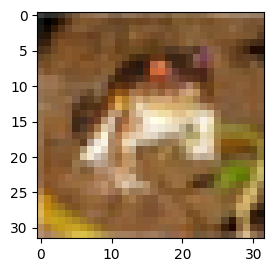

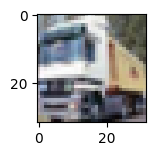

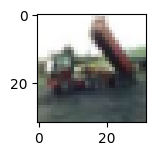

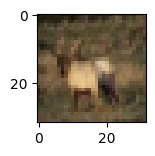

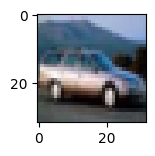

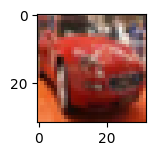

In [6]:
n=6
plt.figure(figsize=(20,10))
for i in range(n):
  plt.subplot(330+1+i)
  plt.imshow(train_X[i])
  plt.show()

### 3) Import the required layers and modules to create our convolution neural net architecture

In [7]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.constraints import MaxNorm
from keras.optimizers import SGD
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.utils import to_categorical

### 4) Convert the pixel values of the dataset to float type and then normalize the dataset

In [8]:
train_x=train_X.astype('float32')
test_X=test_X.astype('float32')

train_X=train_X/255.0
test_X=test_X/255.0

### 5) Now performing the one-hot encoding for target classes

In [9]:
train_Y = to_categorical(train_Y)
test_Y = to_categorical(test_Y)

num_classes = test_Y.shape[1]

### 6) Create the sequential model and add the layers

In [10]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(32, 32, 3),
                 padding='same', activation='relu',
                 kernel_constraint=MaxNorm(3)))

model.add(Dropout(0.2))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                 kernel_constraint=MaxNorm(3)))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu', kernel_constraint=MaxNorm(3)))

model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 7) Configuring the optimizer and compile the model

In [11]:
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=False)

model.compile(loss='categorical_crossentropy',
              optimizer=sgd,
              metrics=['accuracy'])

### 8) Viewing the model summary for better understanding of model architecture

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,210,090 (16.06 MB)

 Trainable params: 4,210,090 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

### 9) Training the model

In [13]:
model.fit(train_X,train_Y,
    validation_data=(test_X,test_Y),
    epochs=10,batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 211s 134ms/step - accuracy: 0.3891 - loss: 1.6828 - val_accuracy: 0.5020 - val_loss: 1.3663
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 213s 137ms/step - accuracy: 0.5160 - loss: 1.3429 - val_accuracy: 0.5766 - val_loss: 1.1791
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 258s 134ms/step - accuracy: 0.5792 - loss: 1.1826 - val_accuracy: 0.6147 - val_loss: 1.0896
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.6329 - loss: 1.0426 - val_accuracy: 0.6345 - val_loss: 1.0374
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 129ms/step - accuracy: 0.6726 - loss: 0.9249 - val_accuracy: 0.6528 - val_loss: 0.9880
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 130ms/step - accuracy: 0.7074 - loss: 0.8319 - val_accuracy: 0.6634 - val_loss: 0.9623
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.7387 - loss: 0.7439 - val_accuracy: 0.6741 - val_loss: 0.9653
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - ac

### 10) Calculating its accuracy on testing data

In [14]:
_,acc=model.evaluate(test_X,test_Y)
print(acc*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6724 - loss: 1.0624
67.23999977111816


### 11) Saving the model

In [15]:
model.save("model1_cifar_10epoch.h5")

### 12) Make a dictionary to map to the output classes and make predictions from the model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Class ID: 3, Prediction: cat


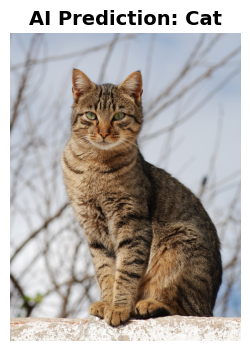

In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Cat_November_2010-1a.jpg"

# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Class ID: 5, Prediction: dog


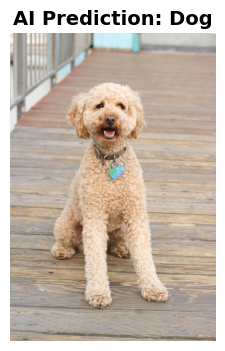

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Rusty.jpg"

# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Class ID: 0, Prediction: aeroplane


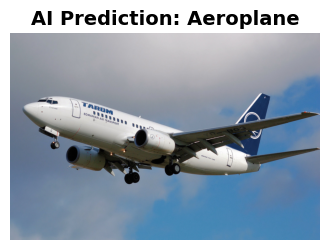

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Tarom.b737-700.yr-bgg.arp.jpg"

# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Class ID: 6, Prediction: frog


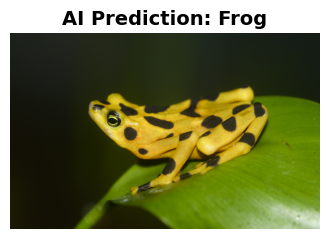

In [23]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Atelopus_zeteki1.jpg"

# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Class ID: 7, Prediction: horse


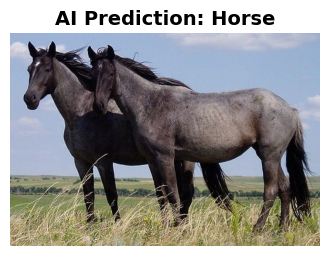

In [25]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Nokota_Horses_cropped.jpg"
# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Class ID: 6, Prediction: frog


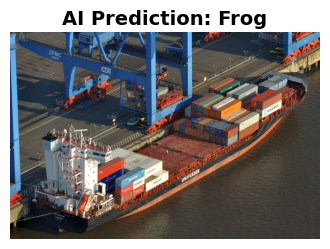

In [26]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dictionary of class labels
results = {
   0: 'aeroplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
   5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

image_path = "/Containerterminal_Altenwerder_(Hamburg-Altenwerder).Iris_Bolten.4.phb.ajb.jpg"
# 1. Load and process the image for the model
im = Image.open(image_path)
im_resized = im.convert('RGB').resize((32, 32))
im_array = np.array(im_resized)

# Normalize the image
im_array = im_array.astype('float32') / 255.0
im_array = np.expand_dims(im_array, axis=0)

# 2. Predict
predictions = model.predict(im_array)
pred = np.argmax(predictions, axis=-1)[0]

print(f"Class ID: {pred}, Prediction: {results[pred]}")

# 3. Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im) # We show the original 'im' here so it isn't a blurry 32x32 square!
plt.title(f"AI Prediction: {results[pred].title()}", fontsize=14, fontweight='bold')
plt.axis('off') # This hides the graph axes and numbers
plt.show()

###  Error Analysis: Why did the AI mistake a Ship for a Frog?

It might seem hilarious that a neural network could confuse a massive metal ship with a tiny green amphibian. However, in the world of computer vision, this mistake actually makes perfect sense! Here is why our model got confused:

*   **The 32x32 Pixel Problem:** The CIFAR-10 dataset squishes every image into a microscopic 32x32 pixel grid. To the AI, it doesn't see sails or lily pads; it just sees blurry blobs of color. A rounded ship hull can easily share the exact same pixel silhouette as a resting frog.
*   **Background & Color Confusion:** Convolutional Neural Networks (CNNs) look for patterns in colors and edges. If the picture features a green or brown ship sitting in blue water, the AI's math might perfectly align with its mathematical definition of a frog (a green/brown blob surrounded by a blue/watery background).
*   **Limited Training (68% Accuracy):** Our model achieved an accuracy of roughly 68% after 10 epochs of training. This means it is statistically expected to get roughly 3 out of every 10 images wrong. It has learned basic features, but it hasn't trained long enough to grasp the deep, complex differences between all 10 classes.

**Takeaway:** This is a perfect example of why **Error Analysis** is a crucial step in Machine Learning. AI doesn't "see" the world with human logic; it only sees patterns of numbers. Understanding *how* it fails helps us design better, deeper models in the future!